# AAV5 -- Revisiter le filtre `viab`

Le filtre `viab` actuel (`AAV5_organoides_sorted.csv`, cf. `obsolete/AAV5_SEL_sorting.ipynb` §5)
retire le 7m8 (hamming<=2 au spike-in LGETTRP) ET borne `compte_plasmide` a `[10, 500]` -- un choix
fait a tatons a l'epoque, jamais compare a une version moins agressive.

Motivation (session 2026-09-14, cf. discussion sur `AAV5_SEL_fitting_protocol_org2org3.ipynb`) :
sur ce CSV, `log2_enrichissement_virus_sur_plasmide` est deja bimodal (un mode "non-fit" ~-2.9, un
mode "fit" ~+0.9/+1.4, meme structure que `fit4functionaav9.csv`) -- des variants disparaissent
reellement a l'etape virus, ce n'est PAS un artefact a filtrer. La question ouverte : le bornage
`[10, 500]` sur `compte_plasmide` deforme-t-il cette bimodalite (coupe-t-il une partie du mode
non-fit ou du mode fit) ?

Ce notebook reprend le filtre depuis zero, une etape a la fois, sans bornage arbitraire :
1. retrait 7m8 seul (identique aux autres notebooks de tri)
2. + retrait des vrais comptages nuls (`compte_plasmide == 0` et/ou `compte_virus == 0` -- les
   seules valeurs pour lesquelles le ratio `virus/plasmide` est indefini)
3. comparaison des 4 distributions (brut / 7m8 retire / +comptages nuls retires / ancien filtre
   `[10,500]`) pour voir ce que chaque etape change reellement.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks

# --- locate the confidential AAV5 organoid CSV (never commit / push / upload) ---
CSV_PATH = Path("AAV5_organoides.csv")
if not CSV_PATH.exists():
    here = Path.cwd()
    root = next(p for p in [here, *here.parents] if p.name == "Modelization_V2")
    CSV_PATH = root / "notebooks/notebooks/Selectivity/AAV5/AAV5_organoides.csv"
assert CSV_PATH.exists(), CSV_PATH

viab_col = "log2_enrichissement_virus_sur_plasmide"
count_cols = ["compte_plasmide", "compte_virus"]
use_cols = ["sequence", *count_cols, viab_col]
dtypes = {"sequence": "string", **{c: "float32" for c in count_cols}, viab_col: "float32"}

df = pd.read_csv(CSV_PATH, usecols=use_cols, dtype=dtypes)
df["sequence"] = df["sequence"].astype("string")
print(df.shape)

# Hamming distance to the 7m8 spike-in (LGETTRP) -- meme calcul que les autres notebooks de tri.
WT = "LGETTRP"
char = np.frombuffer("".join(df["sequence"]).encode("ascii"), np.uint8).reshape(len(df), 7)
ham = (char != np.frombuffer(WT.encode(), np.uint8)).sum(axis=1).astype(np.int16)
df["hamming_to_7m8"] = ham
not_7m8 = ham > 2
print(f"variants a hamming <= 2 du 7m8 (retires) : {int((~not_7m8).sum()):,}")

(5595543, 4)


variants a hamming <= 2 du 7m8 (retires) : 274


## 1. Comptages nuls -- ampleur

In [2]:
plasmid = df["compte_plasmide"].to_numpy(np.float64)
virus   = df["compte_virus"].to_numpy(np.float64)
viab_raw = df[viab_col].to_numpy(np.float64)

print(f"compte_plasmide == 0 : {int((plasmid == 0).sum()):,}  ({(plasmid == 0).mean():.2%})")
print(f"compte_virus == 0    : {int((virus == 0).sum()):,}  ({(virus == 0).mean():.2%})")
print(f"les deux a 0          : {int(((plasmid == 0) & (virus == 0)).sum()):,}")
print(f"viab (brut) non-fini : {int((~np.isfinite(viab_raw)).sum()):,}  "
      f"({(~np.isfinite(viab_raw)).mean():.2%})  -- attendu ~= plasmide==0 (ratio indefini)")

compte_plasmide == 0 : 550,498  (9.84%)
compte_virus == 0    : 0  (0.00%)
les deux a 0          : 0
viab (brut) non-fini : 550,498  (9.84%)  -- attendu ~= plasmide==0 (ratio indefini)


## 2. Filtre A -- retrait 7m8 seul

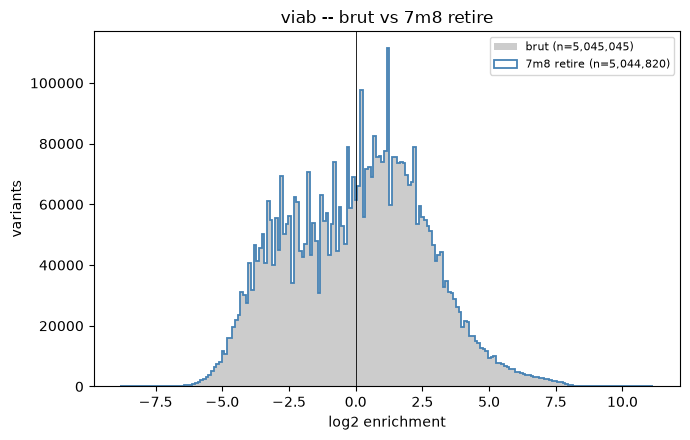

In [3]:
df_ham = df.loc[not_7m8].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 4.5))
a = df[viab_col].to_numpy(np.float64);      a = a[np.isfinite(a)]
b = df_ham[viab_col].to_numpy(np.float64);  b = b[np.isfinite(b)]
bins = np.histogram_bin_edges(a, bins=200)
ax.hist(a, bins=bins, color="0.8", label=f"brut (n={a.size:,})")
ax.hist(b, bins=bins, histtype="step", color="steelblue", lw=1.3, label=f"7m8 retire (n={b.size:,})")
ax.axvline(0, color="k", lw=0.6)
ax.set(title="viab -- brut vs 7m8 retire", xlabel="log2 enrichment", ylabel="variants")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. Filtre B -- + retrait des comptages nuls

In [4]:
zero_plasmid = df_ham["compte_plasmide"].to_numpy(np.float64) == 0
zero_virus   = df_ham["compte_virus"].to_numpy(np.float64) == 0
drop_zero = zero_plasmid | zero_virus

print(f"variants (7m8 retire)               : {len(df_ham):,}")
print(f"  compte_plasmide == 0               : {int(zero_plasmid.sum()):,}")
print(f"  compte_virus == 0                  : {int(zero_virus.sum()):,}")
print(f"  retires (union)                     : {int(drop_zero.sum()):,}")

df_nz = df_ham.loc[~drop_zero].drop(columns=["hamming_to_7m8"]).reset_index(drop=True)
print(f"variants conserves (CSV de travail)  : {len(df_nz):,}  ({len(df_nz) / len(df):.1%} du brut)")

variants (7m8 retire)               : 5,595,269
  compte_plasmide == 0               : 550,449
  compte_virus == 0                  : 0
  retires (union)                     : 550,449
variants conserves (CSV de travail)  : 5,044,820  (90.2% du brut)


## 4. Distributions dans chaque cas

4 etapes cote a cote : brut, 7m8 retire, +comptages nuls retires, et l'ancien filtre
`[10, 500]` (`AAV5_organoides_sorted.csv`, pour comparaison directe -- charge seulement si le
fichier existe deja).

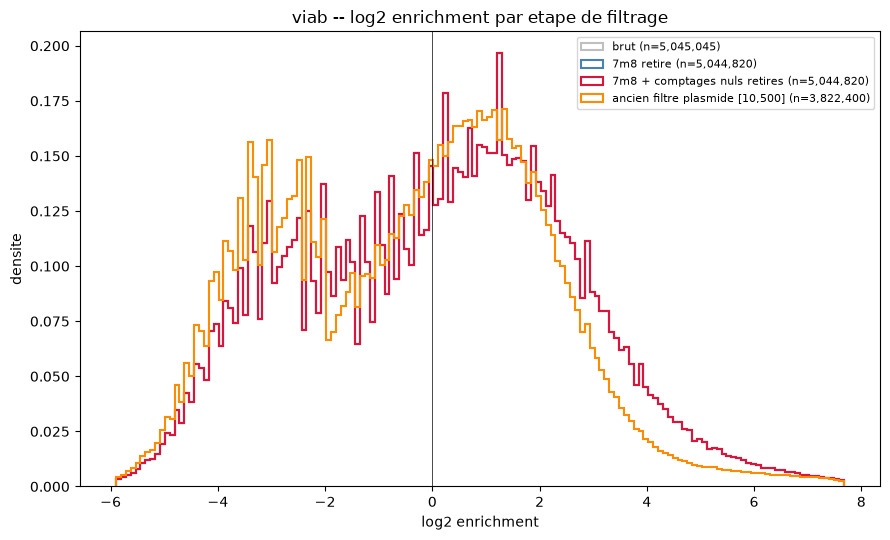


brut                               n=5,045,045  pics (find_peaks, prominence>=5% du max) : -2.73, -2.13, -1.73, -1.13, +0.27, +1.27
7m8 retire                         n=5,044,820  pics (find_peaks, prominence>=5% du max) : -2.73, -2.13, -1.73, -1.13, +0.27, +1.27
7m8 + comptages nuls retires       n=5,044,820  pics (find_peaks, prominence>=5% du max) : -2.73, -2.13, -1.73, -1.13, +0.27, +1.27
ancien filtre plasmide [10,500]    n=3,822,400  pics (find_peaks, prominence>=5% du max) : -3.25, -2.90, -2.21, +0.89


In [5]:
stages = [
    ("brut", df[viab_col].to_numpy(np.float64), "0.75"),
    ("7m8 retire", df_ham[viab_col].to_numpy(np.float64), "steelblue"),
    ("7m8 + comptages nuls retires", df_nz[viab_col].to_numpy(np.float64), "crimson"),
]

OLD_SORTED = CSV_PATH.with_name("AAV5_organoides_sorted.csv")
if OLD_SORTED.exists():
    old = pd.read_csv(OLD_SORTED, usecols=[viab_col], dtype={viab_col: "float32"})[viab_col].to_numpy(np.float64)
    stages.append(("ancien filtre plasmide [10,500]", old, "darkorange"))
else:
    print(f"{OLD_SORTED.name} absent -- comparaison a l'ancien filtre ignoree")

fig, ax = plt.subplots(figsize=(9, 5.5))
finite_nz = df_nz[viab_col].to_numpy(np.float64)
lo, hi = np.percentile(finite_nz[np.isfinite(finite_nz)], [0.1, 99.9])
bins = np.linspace(lo, hi, 150)
for label, arr, color in stages:
    finite = arr[np.isfinite(arr)]
    ax.hist(finite, bins=bins, density=True, histtype="step", lw=1.5, color=color,
            label=f"{label} (n={finite.size:,})")
ax.axvline(0, color="k", lw=0.5)
ax.set(title="viab -- log2 enrichment par etape de filtrage", xlabel="log2 enrichment", ylabel="densite")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print()
for label, arr, _ in stages:
    finite = arr[np.isfinite(arr)]
    counts, edges = np.histogram(finite, bins=100)
    peaks, _ = find_peaks(counts, prominence=counts.max() * 0.05)
    centers = [(edges[p] + edges[p + 1]) / 2 for p in peaks]
    print(f"{label:<34s} n={finite.size:>9,}  pics (find_peaks, prominence>=5% du max) : "
          + ", ".join(f"{c:+.2f}" for c in centers))

## 5. CSV de travail

Exploratoire -- **pas encore adopte comme remplacement** de `AAV5_organoides_sorted.csv` (qui
reste utilise tel quel par `AAV5_SEL_potts_readout_depth.ipynb` et par les fichiers `_sel*` derives
dans `AAV5_sel_sorting.ipynb`). Ecrit sous un nom distinct pour ne rien casser en aval ; a
valider ensemble avant de reporter ce filtre ailleurs.

In [6]:
OUT = CSV_PATH.with_name("AAV5_organoides_sorted_viab.csv")
df_nz.to_csv(OUT, index=False)
print(f"ecrit {OUT.name}  ({df_nz.shape[0]:,} lignes x {df_nz.shape[1]} colonnes)")

ecrit AAV5_organoides_sorted_viab.csv  (5,044,820 lignes x 4 colonnes)


## 6. Diagnostic -- quantification des comptages a faible profondeur

Hypothese (confirmee ci-dessous) : `compte_plasmide`/`compte_virus` sont TOUJOURS des multiples
exacts de 0.5 (le "quantum" de comptage de ce CSV). En dessous de `compte_plasmide < 5`, il n'existe
que 10 valeurs possibles dans TOUT le dataset -- des centaines de milliers de variants differents
partagent donc forcement les memes couples (plasmide, virus), et donc le meme ratio
`log2(virus/plasmide)`, purement par manque de resolution de comptage, pas par similarite
biologique. C'est ca qui cree les pics fins observes en section 4.

In [7]:
p_all = df["compte_plasmide"].to_numpy(np.float64)
v_all = df["compte_virus"].to_numpy(np.float64)
print(f"plasmide -- fraction multiple exact de 0.5 : {np.isclose((p_all * 2) % 1, 0).mean():.4f}")
print(f"virus    -- fraction multiple exact de 0.5 : {np.isclose((v_all * 2) % 1, 0).mean():.4f}")

for thr in (5, 10, 20, 50):
    m = p_all < thr
    print(f"compte_plasmide < {thr:>3d} : {int(m.sum()):>9,} variants, "
          f"seulement {len(np.unique(p_all[m])):>3d} valeurs de plasmide possibles")

plasmide -- fraction multiple exact de 0.5 : 1.0000
virus    -- fraction multiple exact de 0.5 : 1.0000
compte_plasmide <   5 :   968,870 variants, seulement  10 valeurs de plasmide possibles
compte_plasmide <  10 : 1,772,917 variants, seulement  20 valeurs de plasmide possibles
compte_plasmide <  20 : 3,354,985 variants, seulement  40 valeurs de plasmide possibles
compte_plasmide <  50 : 5,252,122 variants, seulement 100 valeurs de plasmide possibles


## 7. Dithering -- lisser l'artefact de discretisation (visualisation uniquement)

On ajoute un bruit `Uniform(-0.25, +0.25)` (la moitie du quantum 0.5) a `compte_plasmide` et
`compte_virus` avant de recalculer `log2((virus+dither+EPS)/(plasmide+dither+EPS))` -- bruit centre
sur 0, donc ca ne biaise pas la forme de la distribution, ca casse juste les egalites artificielles
entre variants qui partagent le meme couple de comptages par manque de resolution. **Uniquement pour
juger de la vraie forme (bimodale ou pas) a l'oeil** -- ne remplace PAS les comptages reels dans un
fit en aval (la ponderation inverse-variance deja utilisee ailleurs dans le projet, `w = 1/(1/(n+eps)
+ 1/(m+eps))`, gere deja correctement l'incertitude des petits comptages pour la regression, cf.
consigne permanente eps=0.5 en tete de CLAUDE.md).

Applique sur `df_nz` (7m8 + comptages nuls retires, meme population que la section 4) pour isoler
l'effet du dithering seul, sans melanger avec le changement de population.

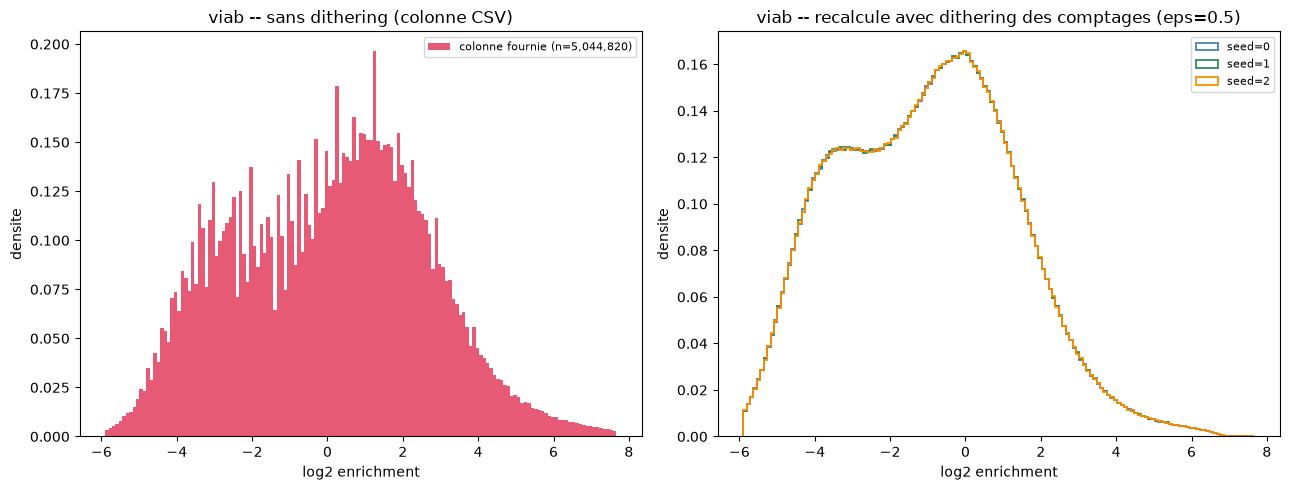


colonne fournie (pas de dithering)     pics : -2.73, -2.13, -1.73, -1.13, +0.27, +1.27
ditheree, seed=0                       pics : -0.02
ditheree, seed=1                       pics : -0.00
ditheree, seed=2                       pics : -0.01


In [8]:
EPS = 0.5  # convention projet -- toujours eps=0.5 pour un log enrichment recalcule par nous-memes

p_nz = df_nz["compte_plasmide"].to_numpy(np.float64)
v_nz = df_nz["compte_virus"].to_numpy(np.float64)
raw_nz = df_nz[viab_col].to_numpy(np.float64)  # colonne fournie, non recalculee -- reference

def dithered_viab(seed):
    rng = np.random.default_rng(seed)
    p_d = p_nz + rng.uniform(-0.25, 0.25, size=p_nz.shape)
    v_d = v_nz + rng.uniform(-0.25, 0.25, size=v_nz.shape)
    return np.log2((v_d + EPS) / (p_d + EPS))

dithered = [dithered_viab(s) for s in (0, 1, 2)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lo, hi = np.percentile(raw_nz[np.isfinite(raw_nz)], [0.1, 99.9])
bins = np.linspace(lo, hi, 150)

axes[0].hist(raw_nz[np.isfinite(raw_nz)], bins=bins, density=True, color="crimson", alpha=0.7,
             label=f"colonne fournie (n={np.isfinite(raw_nz).sum():,})")
axes[0].set(title="viab -- sans dithering (colonne CSV)", xlabel="log2 enrichment", ylabel="densite")
axes[0].legend(fontsize=8)

colors = ["steelblue", "seagreen", "darkorange"]
for arr, c, seed in zip(dithered, colors, (0, 1, 2)):
    axes[1].hist(arr[np.isfinite(arr)], bins=bins, density=True, histtype="step", lw=1.3, color=c,
                 label=f"seed={seed}")
axes[1].set(title="viab -- recalcule avec dithering des comptages (eps=0.5)",
            xlabel="log2 enrichment", ylabel="densite")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print()
counts, edges = np.histogram(raw_nz[np.isfinite(raw_nz)], bins=100)
peaks, _ = find_peaks(counts, prominence=counts.max() * 0.05)
centers = [(edges[k] + edges[k + 1]) / 2 for k in peaks]
print(f"{'colonne fournie (pas de dithering)':<38s} pics : " + ", ".join(f"{c:+.2f}" for c in centers))

for arr, seed in zip(dithered, (0, 1, 2)):
    finite = arr[np.isfinite(arr)]
    counts, edges = np.histogram(finite, bins=100)
    peaks, _ = find_peaks(counts, prominence=counts.max() * 0.05)
    centers = [(edges[k] + edges[k + 1]) / 2 for k in peaks]
    print(f"{'ditheree, seed=' + str(seed):<38s} pics : " + ", ".join(f"{c:+.2f}" for c in centers))

## 8. Le dithering casse TOUTE la structure -- pas juste les pics fins

Regarder les pics `find_peaks` seuls ne suffit pas : imprimer l'histogramme complet en detail
(ci-dessous) montre qu'apres dithering, `df_nz` (7m8 + comptages nuls retires -- population COMPLETE,
y compris tous les tres petits comptages de plasmide) devient **unimodal**, une seule bosse large
centree pres de 0, decroissante des deux cotes, sans aucun epaulement. Le dithering ne fait donc pas
qu'effacer les pics fins -- il montre que sur cette population, il n'y a PAS de vraie bimodalite
fit/non-fit residuelle une fois le bruit de comptage retire.

In [9]:
y_full_dither = dithered[0]
lo, hi = np.percentile(y_full_dither[np.isfinite(y_full_dither)], [0.1, 99.9])
counts, edges = np.histogram(y_full_dither[np.isfinite(y_full_dither)], bins=40, range=(lo, hi))
for i in range(0, 40, 1):
    bar = "#" * int(counts[i] / 2000)
    print(f"{edges[i]:+6.2f} to {edges[i + 1]:+6.2f}: {counts[i]:>8d} {bar}")

 -6.32 to  -6.01:     8627 ####
 -6.01 to  -5.69:    18172 #########
 -5.69 to  -5.38:    35836 #################
 -5.38 to  -5.06:    61005 ##############################
 -5.06 to  -4.75:    92731 ##############################################
 -4.75 to  -4.43:   126488 ###############################################################
 -4.43 to  -4.11:   156580 ##############################################################################
 -4.11 to  -3.80:   178988 #########################################################################################
 -3.80 to  -3.48:   192086 ################################################################################################
 -3.48 to  -3.17:   196650 ##################################################################################################
 -3.17 to  -2.85:   196252 ##################################################################################################
 -2.85 to  -2.53:   195186 #####################################

## 9. Meme test sur l'ancien filtre `[10, 500]` -- la bimodalite survit-elle au dithering ?

Si la bimodalite qu'on croyait voir sur `AAV5_organoides_sorted.csv` (ancien filtre, section 4)
etait, elle aussi, un pur artefact de discretisation, le dithering devrait la faire disparaitre de
la meme facon. Sinon, ca voudrait dire que la bimodalite genuine EXISTE mais seulement parmi les
variants a comptage plasmide suffisant -- et que le filtre `[10,500]`, loin d'etre juste "agressif a
tatons", faisait un vrai travail utile en retirant une masse de variants a tres faible profondeur
dont le bruit de mesure noie le signal une fois qu'on en tient compte correctement (alors qu'il
CREAIT une illusion de structure fine tant qu'on ne dithered pas).

In [10]:
OLD_SORTED = CSV_PATH.with_name("AAV5_organoides_sorted.csv")
if OLD_SORTED.exists():
    old_cnt = pd.read_csv(OLD_SORTED, usecols=["compte_plasmide", "compte_virus"],
                           dtype="float32")
    p_old = old_cnt["compte_plasmide"].to_numpy(np.float64)
    v_old = old_cnt["compte_virus"].to_numpy(np.float64)

    rng = np.random.default_rng(0)
    p_old_d = p_old + rng.uniform(-0.25, 0.25, size=p_old.shape)
    v_old_d = v_old + rng.uniform(-0.25, 0.25, size=v_old.shape)
    y_old_dither = np.log2((v_old_d + EPS) / (p_old_d + EPS))

    lo, hi = np.percentile(y_old_dither, [0.1, 99.9])
    counts, edges = np.histogram(y_old_dither, bins=40, range=(lo, hi))
    for i in range(0, 40, 1):
        bar = "#" * int(counts[i] / 1000)
        print(f"{edges[i]:+6.2f} to {edges[i + 1]:+6.2f}: {counts[i]:>8d} {bar}")

    peaks, _ = find_peaks(counts, prominence=counts.max() * 0.03)
    valleys, _ = find_peaks(-counts, prominence=counts.max() * 0.03)
    print()
    print("pics   :", [f"{(edges[k] + edges[k + 1]) / 2:+.2f}" for k in peaks])
    print("vallees:", [f"{(edges[k] + edges[k + 1]) / 2:+.2f}" for k in valleys])
else:
    print(f"{OLD_SORTED.name} absent -- test ignore")

 -6.42 to  -6.10:     6601 ######
 -6.10 to  -5.78:    15068 ###############
 -5.78 to  -5.46:    29851 #############################
 -5.46 to  -5.15:    53722 #####################################################
 -5.15 to  -4.83:    84197 ####################################################################################
 -4.83 to  -4.51:   118187 ######################################################################################################################
 -4.51 to  -4.20:   149926 #####################################################################################################################################################
 -4.20 to  -3.88:   175012 ###############################################################################################################################################################################
 -3.88 to  -3.56:   188580 ########################################################################################################################

## 10. Sweep du seuil bas `compte_plasmide` (avec dithering a chaque fois)

Si le seuil de 10 fait vraiment le travail, la bimodalite devrait apparaitre progressivement en
augmentant le seuil bas depuis 0. Un seul dithering (seed=0) par seuil -- a `n` de plusieurs
centaines de milliers de lignes, le bruit d'echantillonnage du dithering lui-meme est negligeable
(deja verifie section 7 : les pics sont stables sur 3 seeds differents pour `df_nz`).

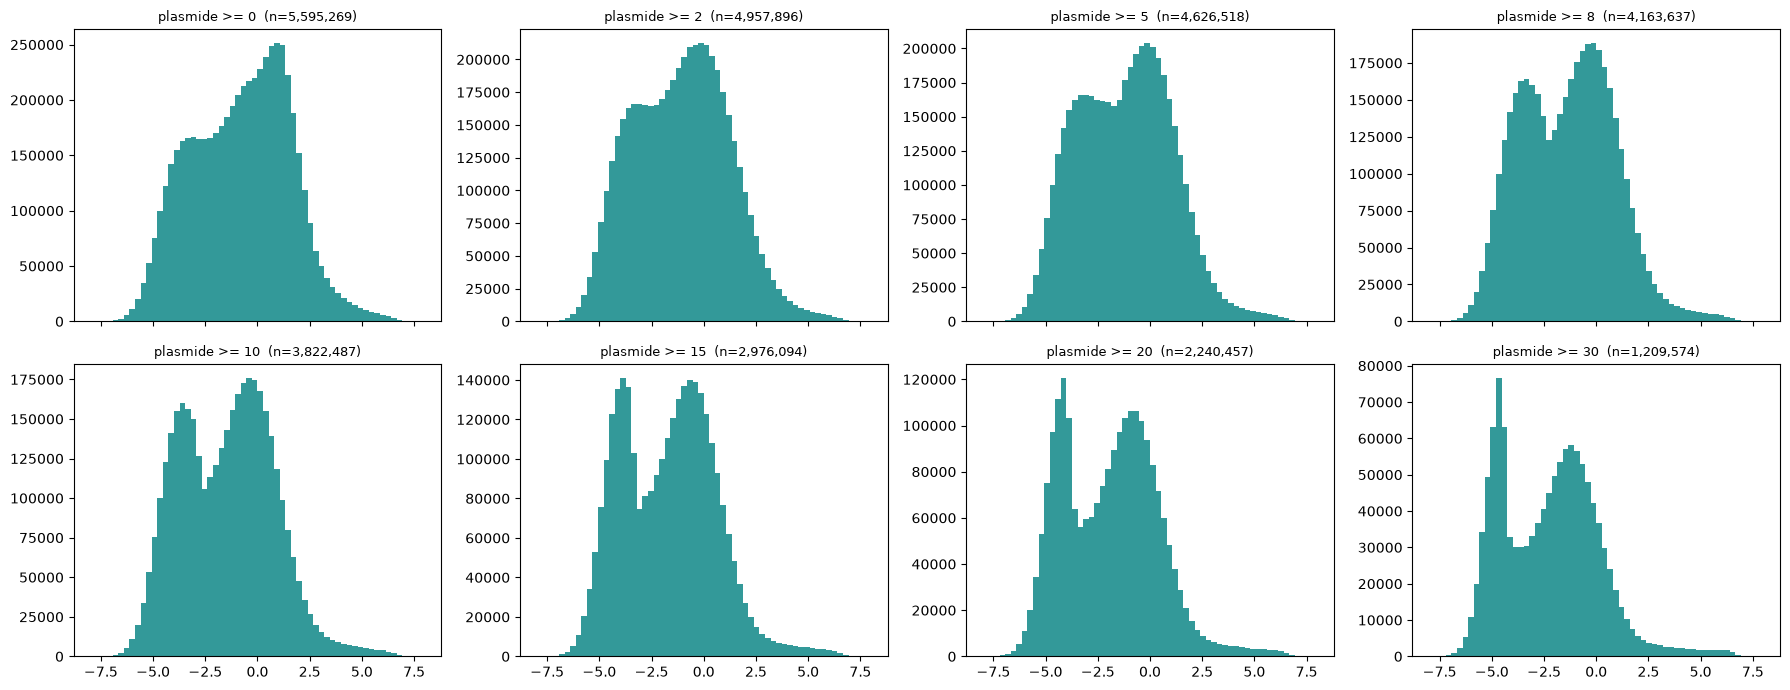

,n,n_peaks_detectes,valley_over_peaks_ratio
plasmid_min,,,
0,5595269,1,NaN
2,4957896,1,NaN
5,4626518,1,NaN
8,4163637,2,0.699
10,3822487,2,0.630
15,2976094,2,0.533
20,2240457,2,0.495
30,1209574,2,0.447


In [11]:
PLASMID_MIN_GRID = [0, 2, 5, 8, 10, 15, 20, 30]

fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharex=True)
rows = []
for ax, thr in zip(axes.flat, PLASMID_MIN_GRID):
    keep = not_7m8 & (df["compte_plasmide"].to_numpy(np.float64) >= thr)
    p_t = df.loc[keep, "compte_plasmide"].to_numpy(np.float64)
    v_t = df.loc[keep, "compte_virus"].to_numpy(np.float64)

    rng = np.random.default_rng(0)
    p_td = p_t + rng.uniform(-0.25, 0.25, size=p_t.shape)
    v_td = v_t + rng.uniform(-0.25, 0.25, size=v_t.shape)
    y_td = np.log2((v_td + EPS) / (p_td + EPS))

    lo, hi = -8, 8
    counts, edges = np.histogram(y_td, bins=60, range=(lo, hi))
    ax.bar((edges[:-1] + edges[1:]) / 2, counts, width=(hi - lo) / 60, color="teal", alpha=0.8)
    ax.set_title(f"plasmide >= {thr}  (n={len(p_t):,})", fontsize=9)

    peaks, peak_props = find_peaks(counts, prominence=counts.max() * 0.05)
    valleys, _ = find_peaks(-counts, prominence=counts.max() * 0.05)
    n_peaks = len(peaks)
    valley_ratio = None
    if n_peaks >= 2 and len(valleys) >= 1:
        # valley entre les 2 pics les plus proeminents
        top2 = peaks[np.argsort(peak_props["prominences"])[-2:]]
        lo_p, hi_p = sorted(top2)
        mid_valleys = valleys[(valleys > lo_p) & (valleys < hi_p)]
        if len(mid_valleys):
            v = mid_valleys[np.argmin(counts[mid_valleys])]
            valley_ratio = counts[v] / np.mean([counts[lo_p], counts[hi_p]])
    rows.append({"plasmid_min": thr, "n": int(len(p_t)), "n_peaks_detectes": n_peaks,
                 "valley_over_peaks_ratio": None if valley_ratio is None else round(float(valley_ratio), 3)})

plt.tight_layout(); plt.show()
sweep_tbl = pd.DataFrame(rows).set_index("plasmid_min")
display(sweep_tbl)

## 11. Conclusion

**La fragmentation en pics fins de la section 4 est bien un artefact de discretisation (confirme
par dithering) -- mais retirer seulement les comptages nuls ne suffit pas a recuperer la vraie
bimodalite : ca noie le signal sous le bruit des tres petits comptages.**

Table du sweep (section 10), `valley_over_peaks_ratio` = profondeur de la vallee entre les 2 modes
(1 = pas de vraie vallee/unimodal, proche de 0 = 2 modes nettement separes) :

| `plasmid_min` | n         | pics detectes | vallee/pics |
|--------------:|----------:|---------------:|------------:|
| 0             | 5 595 269 | 1 (unimodal)   | --          |
| 2             | 4 957 896 | 1 (unimodal)   | --          |
| 5             | 4 626 518 | 1 (unimodal)   | --          |
| 8             | 4 163 637 | 2              | 0.699       |
| **10**        | 3 822 487 | 2              | **0.630**   |
| 15            | 2 976 094 | 2              | 0.533       |
| 20            | 2 240 457 | 2              | 0.495       |
| 30            | 1 209 574 | 2              | 0.447       |

La bimodalite genuine n'apparait qu'a partir de `compte_plasmide >= 8` et se renforce
progressivement -- en dessous, la population (dominee par les tres faibles comptages, cf. section 6 :
968 870 variants ont `compte_plasmide < 5`, seulement 10 valeurs de comptage possibles) est trop
bruitee pour porter un signal fit/non-fit, meme apres dithering (section 8 : `df_nz`, comptages nuls
seuls retires, est unimodal).

**L'ancien filtre `PLASMID_MIN=10` n'etait donc pas un choix arbitraire "a tatons" -- il tombe
quasiment exactement sur le seuil ou la bimodalite devient robuste.** Monter plus haut (15/20/30)
creuse un peu plus la vallee mais au prix d'une perte de diversite bien plus severe (3.82M -> 1.21M
de 10 a 30, pour un gain de vallee 0.630 -> 0.447 seulement) -- pas clairement un meilleur compromis.

**Recommandation** : garder `AAV5_organoides_sorted.csv` (filtre historique `[10, 500]`) comme CSV
`viab` de reference -- ne pas le remplacer par `AAV5_organoides_sorted_viab.csv` (comptages nuls
seuls retires, section 5 de ce notebook), qui est EXPLORATOIRE et s'est revele insuffisant. Le
dithering (section 7) reste un outil utile a garder en tete pour tout futur diagnostic visuel de
bimodalite sur ce type de donnees (log enrichment a partir de comptages NGS discrets) -- il ne doit
PAS remplacer les comptages reels dans un fit en aval (la ponderation inverse-variance deja en place
gere deja l'incertitude des petits comptages correctement pour la regression).